# Testing de modelos en set de test

Este notebook permite evaluar y comparar modelos de distintos algoritmos
guardados como pipelines del proyecto (LightGBM, RandomForest, XGBoost, LogReg).

## Flujo

1. Detectar o elegir estudios/modelos por algoritmo.
2. Cargar `df_final_test.csv`.
3. Evaluar cada pipeline y comparar metricas globales.
4. Ver matriz de confusion y reporte por clase para un algoritmo.

In [1]:
from pathlib import Path
from typing import Dict, Optional
import json

import joblib
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

/home/francisco/miniconda3/envs/tesis311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Ajustes base
ROOT = Path('.').resolve()
DATASET_DIR = ROOT / 'datasets'
TEST_PATH = DATASET_DIR / 'df_final_test.csv'
CLASS_MAP_PATH = DATASET_DIR / 'class_mapping.json'
OPTUNA_DB = 'sqlite:///optuna.sqlite3'

ALGO_DIRS = {
    'lightgbm': ROOT / 'models' / 'lgbm',
    'randomforest': ROOT / 'models' / 'randomforest',
    'xgboost': ROOT / 'models' / 'xgboost',
    'logreg': ROOT / 'models' / 'logreg',
}

STUDY_PREFIXES = {
    'lightgbm': ['LGBM_', 'lightgbm_'],
    'randomforest': ['RF_', 'randomforest_'],
    'xgboost': ['xgboost_', 'XGBOOST_'],
    'logreg': ['logreg_', 'LOGREG_'],
}

print('ROOT:', ROOT)
print('TEST_PATH exists:', TEST_PATH.exists())

ROOT: /home/francisco/maestrìa/trabajo final/tf-austral
TEST_PATH exists: True


In [3]:
def invert_class_mapping(path: Path) -> Dict[int, str]:
    if not path.exists():
        return {}
    raw = json.loads(path.read_text(encoding='utf-8'))
    return {int(v): str(k) for k, v in raw.items()}


def list_studies_by_algo(storage_url: str) -> Dict[str, list]:
    studies = optuna.get_all_study_summaries(storage=storage_url)
    result = {k: [] for k in ALGO_DIRS.keys()}

    for s in studies:
        for algo, prefixes in STUDY_PREFIXES.items():
            if any(s.study_name.startswith(p) for p in prefixes):
                result[algo].append(s)
                break

    for algo in result:
        result[algo] = sorted(
            result[algo],
            key=lambda x: (x.best_trial.value if x.best_trial else -10**9),
            reverse=True,
        )

    return result


def strip_prefix(study_name: str, algo: str) -> str:
    for prefix in STUDY_PREFIXES[algo]:
        if study_name.startswith(prefix):
            return study_name[len(prefix):]
    return study_name


def find_model_path(algo: str, short_study_name: str) -> Optional[Path]:
    model_root = ALGO_DIRS[algo]
    if not model_root.exists():
        return None

    expected = model_root / short_study_name / f'model_{short_study_name}.pkl'
    if expected.exists():
        return expected

    candidates = sorted(model_root.rglob('model_*.pkl'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        return None

    for c in candidates:
        if short_study_name.lower() in c.stem.lower():
            return c

    return candidates[0]


def choose_study_and_model(algo: str, manual_short_study: Optional[str], studies_cache: Dict[str, list]):
    if manual_short_study:
        model_path = find_model_path(algo, manual_short_study)
        return manual_short_study, model_path

    studies = studies_cache.get(algo, [])
    if studies:
        short_study = strip_prefix(studies[0].study_name, algo)
        model_path = find_model_path(algo, short_study)
        return short_study, model_path

    model_root = ALGO_DIRS[algo]
    if not model_root.exists():
        return None, None

    candidates = sorted(model_root.rglob('model_*.pkl'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        return None, None

    last = candidates[0]
    short_study = last.stem.replace('model_', '', 1)
    return short_study, last

In [7]:
# Opcional: fijar estudios manualmente (None = autodeteccion)
MANUAL_STUDIES = {
    'lightgbm': "lightgbm_dataset_categoricas",
    'randomforest': "RF_dataset_categoricas",
    'xgboost': "xgboost_dataset_categoricas",
    'logreg': "logreg_dataset_categoricas",
}

studies_cache = list_studies_by_algo(OPTUNA_DB)

for algo in ALGO_DIRS.keys():
    best = studies_cache.get(algo, [])
    msg = best[0].study_name if best else 'sin estudio en optuna'
    print(f'{algo:12s} -> {msg}')

lightgbm     -> lightgbm_dataset_bigramas
randomforest -> RF_dataset_bigramas
xgboost      -> xgboost_dataset_bigramas
logreg       -> logreg_dataset_categoricas


In [8]:
if not TEST_PATH.exists():
    raise FileNotFoundError(f'No existe {TEST_PATH}')

df_test = pd.read_csv(TEST_PATH, sep=';')
if 'target' not in df_test.columns:
    raise ValueError('df_final_test.csv no tiene columna target')

df_test['texto_limpio'] = df_test.get('texto_limpio', '').fillna('')
X_test = df_test.drop(columns=['target'], errors='ignore')
y_test = df_test['target'].astype(int)

inv_mapping = invert_class_mapping(CLASS_MAP_PATH)
print('X_test shape:', X_test.shape)
print('y_test clases:', y_test.nunique())

X_test shape: (25357, 173)
y_test clases: 13


In [9]:
def evaluate_pipeline(algo: str, model_path: Path, X: pd.DataFrame, y: pd.Series):
    model = joblib.load(model_path)
    y_pred = pd.Series(model.predict(X)).astype(int)

    metrics = {
        'algorithm': algo,
        'model_path': str(model_path),
        'accuracy': accuracy_score(y, y_pred),
        'kappa': cohen_kappa_score(y, y_pred),
        'f1_macro': f1_score(y, y_pred, average='macro', zero_division=0),
        'precision_macro': precision_score(y, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y, y_pred, average='macro', zero_division=0),
    }

    labels = sorted(set(y.unique()).union(set(y_pred.unique())))
    cm = confusion_matrix(y, y_pred, labels=labels)

    return metrics, y_pred, labels, cm


results_rows = []
predictions_by_algo = {}
cm_by_algo = {}
labels_by_algo = {}

for algo in ALGO_DIRS.keys():
    short_study, model_path = choose_study_and_model(algo, MANUAL_STUDIES.get(algo), studies_cache)

    if model_path is None or not Path(model_path).exists():
        print(f'[SKIP] {algo}: no se encontro modelo para evaluar')
        continue

    print(f'[RUN ] {algo}: {short_study} -> {model_path}')
    metrics, y_pred, labels, cm = evaluate_pipeline(algo, Path(model_path), X_test, y_test)
    metrics['study_name'] = short_study

    results_rows.append(metrics)
    predictions_by_algo[algo] = y_pred
    cm_by_algo[algo] = cm
    labels_by_algo[algo] = labels

results_df = pd.DataFrame(results_rows)
if results_df.empty:
    raise RuntimeError('No hubo modelos evaluados. Revisar MANUAL_STUDIES o carpetas de models/.')

results_df = results_df.sort_values(['kappa', 'accuracy'], ascending=False).reset_index(drop=True)
results_df

[RUN ] lightgbm: lightgbm_dataset_categoricas -> /home/francisco/maestrìa/trabajo final/tf-austral/models/lgbm/dataset_categoricas/model_dataset_categoricas.pkl


/home/francisco/miniconda3/envs/tesis311/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] Unknown parameter: verbose_eval
[RUN ] randomforest: RF_dataset_categoricas -> /home/francisco/maestrìa/trabajo final/tf-austral/models/randomforest/dataset_categoricas/model_dataset_categoricas.pkl
[RUN ] xgboost: xgboost_dataset_categoricas -> /home/francisco/maestrìa/trabajo final/tf-austral/models/xgboost/dataset_categoricas/model_dataset_categoricas.pkl
[RUN ] logreg: logreg_dataset_categoricas -> /home/francisco/maestrìa/trabajo final/tf-austral/models/logreg/dataset_categoricas/model_dataset_categoricas.pkl


,algorithm,model_path,accuracy,kappa,f1_macro,precision_macro,recall_macro,study_name
0,xgboost,/home/francisco/maestrìa/trabajo final/tf-aust...,0.959498,0.948928,0.944093,0.946148,0.943663,xgboost_dataset_categoricas
1,lightgbm,/home/francisco/maestrìa/trabajo final/tf-aust...,0.959301,0.948639,0.943069,0.947251,0.941054,lightgbm_dataset_categoricas
2,logreg,/home/francisco/maestrìa/trabajo final/tf-aust...,0.959222,0.948461,0.944266,0.952347,0.938642,logreg_dataset_categoricas
3,randomforest,/home/francisco/maestrìa/trabajo final/tf-aust...,0.951138,0.938452,0.934754,0.934072,0.937719,RF_dataset_categoricas


Algoritmo seleccionado: logreg


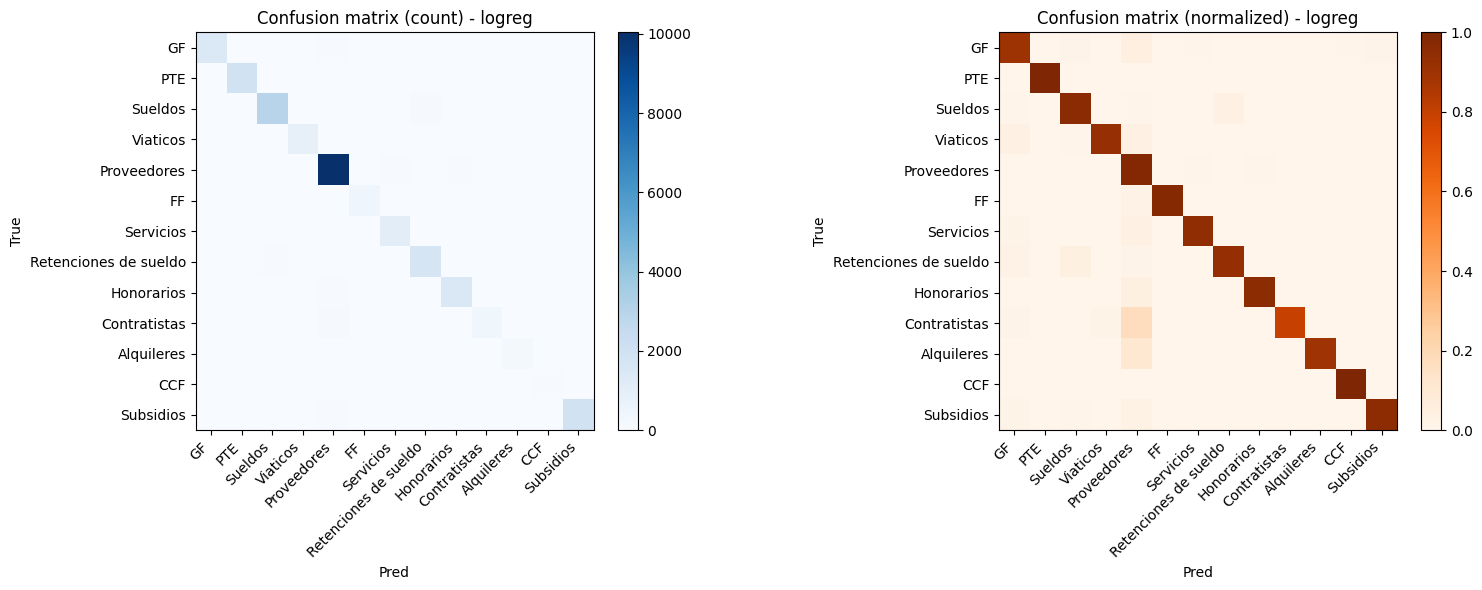

,precision,recall,f1-score,support
0,0.894065,0.899230,0.896640,1558.000000
1,1.000000,0.998408,0.999204,1885.000000
2,0.959779,0.957295,0.958536,3091.000000
3,0.984281,0.922902,0.952604,882.000000
4,0.960563,0.982764,0.971536,10211.000000
5,0.995690,0.976744,0.986126,473.000000
6,0.940594,0.943993,0.942290,1107.000000
7,0.938719,0.926333,0.932485,1819.000000
8,0.952842,0.956550,0.954693,1542.000000
9,0.932836,0.796178,0.859107,471.000000


In [11]:
# Elegir algoritmo para analisis detallado
ALGO_DETAIL = results_df.loc[2, 'algorithm']
print('Algoritmo seleccionado:', ALGO_DETAIL)

y_pred_detail = predictions_by_algo[ALGO_DETAIL]
labels = labels_by_algo[ALGO_DETAIL]
cm = cm_by_algo[ALGO_DETAIL]

label_names = [inv_mapping.get(int(lbl), str(lbl)) for lbl in labels]

cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

im0 = ax[0].imshow(cm, cmap='Blues')
ax[0].set_title(f'Confusion matrix (count) - {ALGO_DETAIL}')
ax[0].set_xlabel('Pred')
ax[0].set_ylabel('True')
ax[0].set_xticks(np.arange(len(label_names)))
ax[0].set_yticks(np.arange(len(label_names)))
ax[0].set_xticklabels(label_names, rotation=45, ha='right')
ax[0].set_yticklabels(label_names)
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(cm_norm, cmap='Oranges', vmin=0, vmax=1)
ax[1].set_title(f'Confusion matrix (normalized) - {ALGO_DETAIL}')
ax[1].set_xlabel('Pred')
ax[1].set_ylabel('True')
ax[1].set_xticks(np.arange(len(label_names)))
ax[1].set_yticks(np.arange(len(label_names)))
ax[1].set_xticklabels(label_names, rotation=45, ha='right')
ax[1].set_yticklabels(label_names)
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

report = classification_report(y_test, y_pred_detail, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df